In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df1=pd.read_csv(r"F:\Omkar_sir_files\CSV_Files\Visadataset (1).csv")
df1


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [5]:
cat=df1.select_dtypes(include='object').columns
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [6]:
num=df1.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [7]:
wage_data=df1['prevailing_wage']
wage_data

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

## **Histogram**

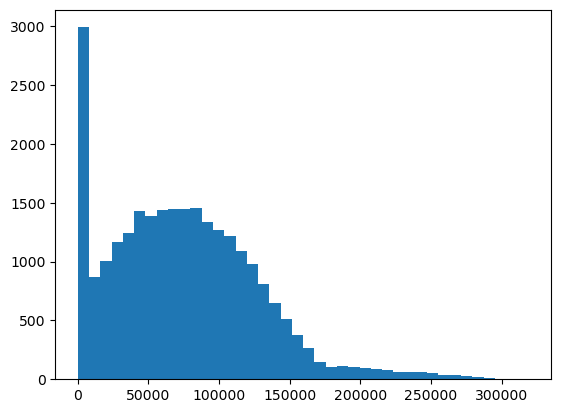

In [14]:
wage_data=df1['prevailing_wage']
plt.hist(wage_data,bins=40)
plt.show()

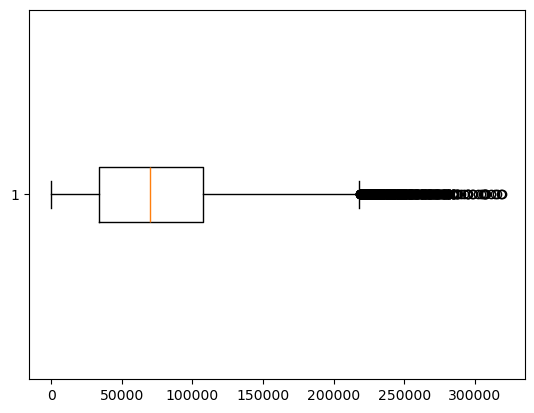

In [16]:
plt.boxplot(wage_data,vert=False)
plt.show()

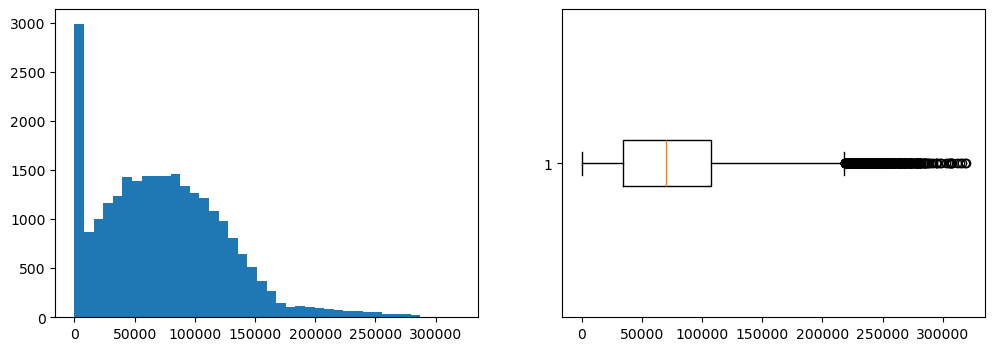

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1).hist(wage_data,bins=40)
plt.subplot(1,2,2).boxplot(wage_data,vert=False)
plt.show()

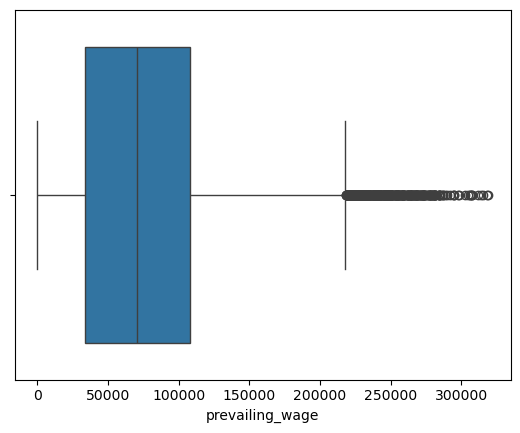

In [19]:
sns.boxplot(wage_data,orient='h')
plt.show()

- Find the number of outliers
- Get outliers data and without data separate

In [23]:
con1=q1-1.5*iqr <wage
concon2=q3+1.5*iqr >wag
con=con1 | con2

NameError: name 'q1' is not defined

In [ ]:
q1=np.percentile(wage_data,25)
# q2=np.percentile(wage_data,50)
q3=np.percentile(wage_data,75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
con1=wage_data<lb
con2=wage_data>ub
con=con1|con2
len(df1[con])




In [26]:
q1=np.percentile(wage_data,25)
q2=np.percentile(wage_data,50)
q3=np.percentile(wage_data,75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
con1=wage_data>lb
con2=wage_data<ub
con=con1&con2
non_outliers_data=df1[con]
len(df1[con])




25053

 25053+427

In [29]:
427/25480

0.016758241758241758

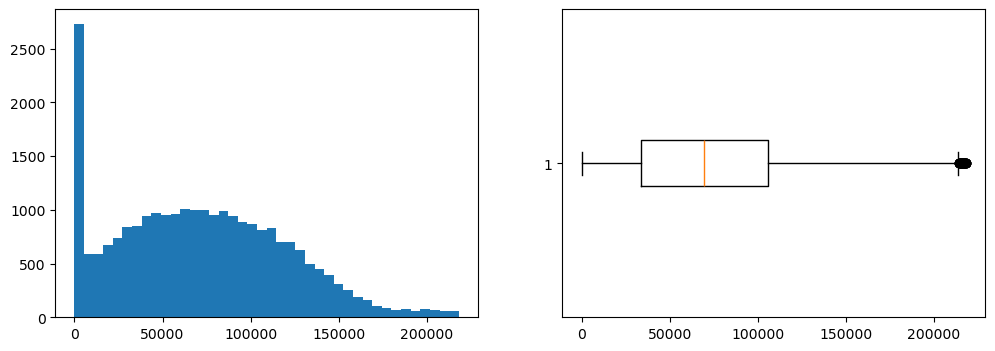

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1).hist(non_outliers_data['prevailing_wage'],bins=40)
plt.subplot(1,2,2).boxplot(non_outliers_data['prevailing_wage'],vert=False)
plt.show()

## **Fill the outlayers with median**

In [34]:
wage_data=df1['prevailing_wage'].values
wage_data_outliers=df1['prevailing_wage'].values

In [36]:
list1=[]
for i in wage_data:
    if i in wage_data_outliers:
        list1.append(np.median(wage_data))
    else:
        list1.append()
df1 = pd.DataFrame()  # Create a DataFrame if it doesn't exist
# df1['prevailing_wage'] = list1 
df1['prevailing_wage']=list1

- Data skwed
- not following normal distribution 
- means outlyers are presenr

## **outliers analysis**

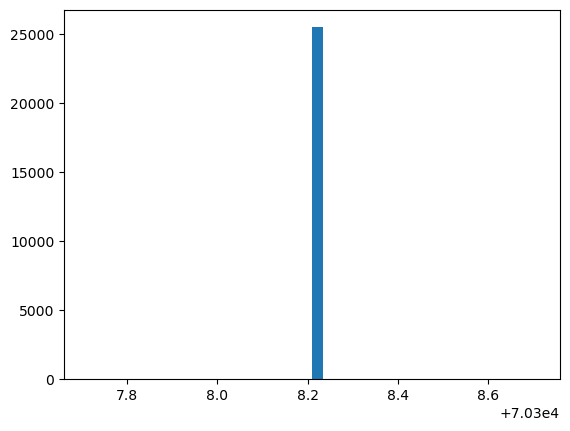

In [39]:
wage_data=df1['prevailing_wage']
plt.hist(wage_data,bins=40)
plt.show()

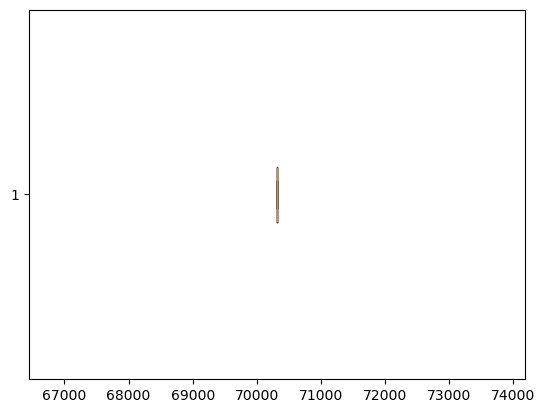

In [40]:
plt.boxplot(wage_data,vert=False)
plt.show()

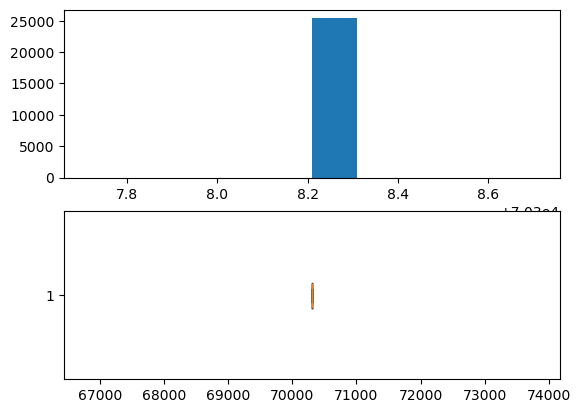

In [41]:
# plt.figure(figsize=(12,4))
plt.subplot(2,1,1).hist(wage_data)
plt.subplot(2,1,2).boxplot(wage_data,vert=False)
plt.show()

## **Outlier Data**

In [43]:
q1=np.percentile(wage_data,25)
q2=np.percentile(wage_data,50)
q3=np.percentile(wage_data,75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
con1=wage_data<lb
con2=wage_data>ub
con=con1|con2
len(df1[con])

0

In [44]:
q1=np.percentile(wage_data,25)
q2=np.percentile(wage_data,50)
q3=np.percentile(wage_data,75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
con1=wage_data>lb
con2=wage_data<ub
con=con1&con2
non_outliers_data=df1[con]
len(df1[con])


0

In [45]:
(427/25480)*100 #

1.6758241758241759

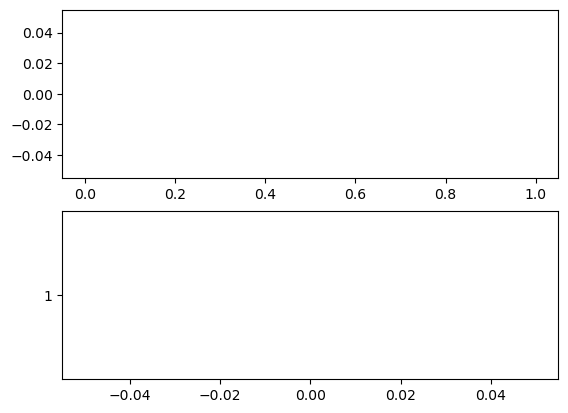

In [46]:
d=non_outliers_data['prevailing_wage']
plt.subplot(2,1,1).hist(d)
plt.subplot(2,1,2).boxplot(d,vert=False)
plt.show()

## **Outliers imputation**

- Method1:
    - lessthan ib outliers impue with lb value
    - greaterthan ub outliers impute with ub value
      
- method2: Every outlier replace with median

In [48]:
l=[]
for i in wage_data:
    if i<lb: #outliers
        l.append(lb)
    elif i>ub:
        l.append(ub)
    else:
        l.append(i)

df1['wage_data_new']=l

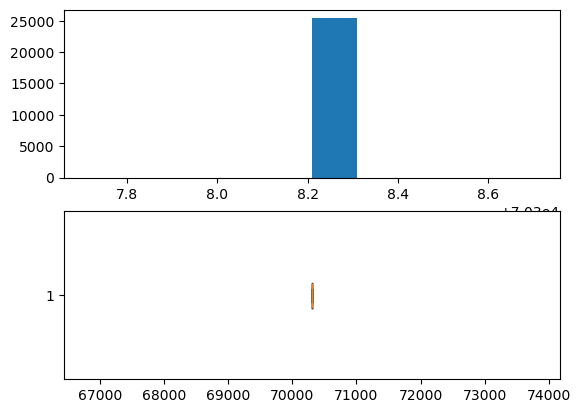

In [60]:
d=df1['wage_data_new']
plt.subplot(2,1,1).hist(d)
plt.subplot(2,1,2).boxplot(d,vert=False)
plt.show()

## Cap:Winsorization

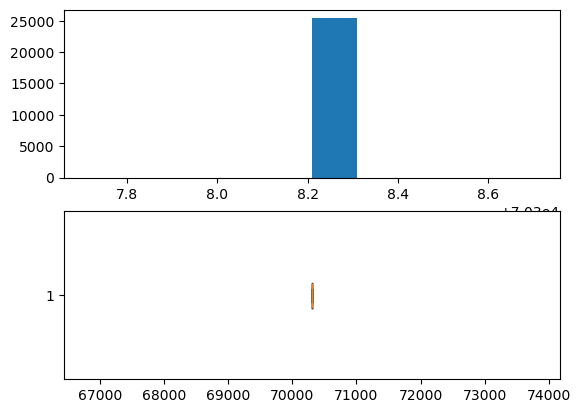

In [57]:
d=df1['prevailing_wage'].clip(lb,ub)
plt.subplot(2,1,1).hist(d)
plt.subplot(2,1,2).boxplot(d,vert=False)
plt.show()